In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        pass
        # print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

no rescalling durin for training and validation generators , as already scaled during preprocess_input()

# Additional Code needed for intermediate Steps , Not part of the preprocessing and training pipeline

In [ ]:
import shutil
import os

INPUT_DIR = "/kaggle/input/datasets/aroshabakhtawar/checkpoints20/kaggle/working/checkpoints"
OUTPUT_DIR = "/kaggle/working/checkpoints"

os.makedirs(OUTPUT_DIR, exist_ok=True)

for file in os.listdir(INPUT_DIR):
    src = os.path.join(INPUT_DIR, file)
    dst = os.path.join(OUTPUT_DIR, file)
    
    if os.path.isfile(src):
        shutil.copy(src, dst)

print("✅ Checkpoints now in output directory")

 #  Step:1 Environment setup and imports

In [1]:
# ==============================
# 📌 STEP 1: IMPORT LIBRARIES
# ==============================

import os 
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from glob import glob
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models , regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix , accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelBinarizer , StandardScaler

from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("✅ Libraries loaded successfully")
print("TensorFlow Version:", tf.__version__)

2026-05-01 16:23:41.096321: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777652621.298550      49 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777652621.359439      49 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

✅ Libraries loaded successfully
TensorFlow Version: 2.18.0


####  Dataset Auto-Exploration

In [ ]:
# # ==============================
# # 📌 STEP 2: DATASET EXPLORATION
# # ==============================

# DATASET_PATH = "/kaggle/input"

# # Find waste dataset folder dynamically
# print("📂 Searching dataset folders...")

# for root, dirs, files in os.walk(DATASET_PATH):
#     if "waste" in root.lower() or "trash" in root.lower():
#         print("🔍 Possible dataset path found:", root)

# # Manually set base path (Kaggle usually has one main folder inside input)
# base_path = glob("/kaggle/input/*")[0]
# print("\n✅ Using base dataset path:", base_path)

# # ==============================
# # 📁 FUNCTION: Explore structure
# # ==============================

# def explore_dataset(path):
#     class_counts = {}
#     all_images = []

#     print("\n📊 Exploring dataset structure...\n")

#     for root, dirs, files in os.walk(path):
#         # If folder contains images
#         images = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

#         if len(images) > 0:
#             class_name = os.path.basename(root)
#             class_counts[class_name] = class_counts.get(class_name, 0) + len(images)

#             for img in images:
#                 all_images.append(os.path.join(root, img))

#     return class_counts, all_images

# # Run exploration
# class_counts, all_images = explore_dataset(base_path)

# # ==============================
# # 📊 CLASS DISTRIBUTION
# # ==============================

# df = pd.DataFrame(list(class_counts.items()), columns=["Class", "Image_Count"])
# df = df.sort_values(by="Image_Count", ascending=False)

# print("\n📌 Class Distribution:")
# print(df)

# # Plot distribution
# plt.figure(figsize=(10,5))
# sns.barplot(x="Class", y="Image_Count", data=df)
# plt.xticks(rotation=90)
# plt.title("Class Distribution (Imbalance Check)")
# plt.show()

# # ==============================
# # 🧪 SAMPLE IMAGES DISPLAY
# # ==============================

# print("\n🖼️ Showing sample images...")

# sample_images = random.sample(all_images, min(9, len(all_images)))

# plt.figure(figsize=(14,8))

# for i, img_path in enumerate(sample_images):
#     img = Image.open(img_path)
#     plt.subplot(3,3,i+1)
#     plt.imshow(img)
#     plt.axis("off")

# plt.tight_layout()
# plt.show()

# print("\n✅ Dataset exploration complete")

# Step: 2 Load Stage 3 Dataset -> DataFrame

In [2]:
# ==============================
# 📌 STEP 3: FILTER FINAL DATASET (THIRD STAGE)
# ==============================

import os
from glob import glob

base_path = "/kaggle/input/waste-datasets"

third_stage_path = os.path.join(base_path, "Dataset_ThirdStage", "Dataset")

print("📂 Using Third Stage Dataset:", third_stage_path)

# Collect class folders
class_folders = sorted([
    d for d in os.listdir(third_stage_path)
    if os.path.isdir(os.path.join(third_stage_path, d))
])

print("\n📊 Total Classes Found:", len(class_folders))
print(class_folders[:10], "...")

# Build dataset dataframe
data = []

for cls in class_folders:
    class_path = os.path.join(third_stage_path, cls)
    images = glob(class_path + "/*.jpg") + glob(class_path + "/*.png") + glob(class_path + "/*.jpeg")
    
    for img in images:
        data.append((img, cls))

df = pd.DataFrame(data, columns=["image_path", "label"])

print("\n✅ Dataset size:", len(df))
print(df.head())

# Class distribution
print("\n📊 New Class Distribution:")
print(df["label"].value_counts())

📂 Using Third Stage Dataset: /kaggle/input/waste-datasets/Dataset_ThirdStage/Dataset

📊 Total Classes Found: 36
['A_Foods', 'B_Animal Dead Body', 'C_Cardboard', 'D_Newspaper', 'E_Paper Cups', 'F_Papers', 'G_Brown Glass', 'H_Porcelin', 'I_Green Glass', 'J_White Glass'] ...

✅ Dataset size: 35209
                                          image_path    label
0  /kaggle/input/waste-datasets/Dataset_ThirdStag...  A_Foods
1  /kaggle/input/waste-datasets/Dataset_ThirdStag...  A_Foods
2  /kaggle/input/waste-datasets/Dataset_ThirdStag...  A_Foods
3  /kaggle/input/waste-datasets/Dataset_ThirdStag...  A_Foods
4  /kaggle/input/waste-datasets/Dataset_ThirdStag...  A_Foods

📊 New Class Distribution:
label
T_Clothes                        5324
A_Foods                          4110
C_Cardboard                      2035
Z_G_Battery                      1988
U_Shoes                          1977
K_Beverage Cans                  1602
Y_Medicine and Medicine Strip    1303
D_Newspaper                      

# Step: 3: Tiered Oversampling (5 Tiers)
Balance the training data so that no class have fewer than 200 samples.This is a simple but highly effective fix for a sever imbalance.

In [3]:
# Exact targets from the tier table above
TIER_TARGETS = {
    # Tier 1 — cap heavy majority
    "T_Clothes": 1200, "A_Foods": 1200,
    "C_Cardboard": 1200, "Z_G_Battery": 1200,

    # Tier 2 — moderate cap
    "U_Shoes": 1000, "K_Beverage Cans": 1000,
    "Y_Medicine and Medicine Strip": 1000, "D_Newspaper": 1000,

    # Tier 3 — keep as-is (no resampling needed)
    "N_Plastic Bag": None, "Z_J_Pesticidebottle": None,
    "Z_H_Thermometer": None, "F_Papers": None,
    "S_Tetra Pak": None, "H_Porcelin": None,
    "Z_A_Diaper": None, "J_White Glass": None,
    "O_Plastic Bottle": None, "Z_E_Small Appliances": None,

    # Tier 4 — oversample to 700
    "I_Green Glass": 700, "G_Brown Glass": 700,
    "Z_B_Electrical Cables": 700, "E_Paper Cups": 700,
    "Z_C_Electronic Chips": 700, "Q_Plastic Containers": 700,
    "M_Metal Containers": 700, "L_Construction Scrap": 700,
    "Z_A_A_Syringe": 700, "R_Plastic Cups": 700,
    "X_Bandai": 700, "Z_K_Spray cans": 700,
    "W_Masks": 700, "Z_D_Laptops": 700, "V_Gloves": 700,

    # Tier 5 — SMOTE zone (handled separately below for features)
    # At image level, still oversample with replacement + heavy augmentation
    "B_Animal Dead Body": 700, "Z_F_Smartphones": 700,
    "Z_I_Cigarette Butt": 700,
    }



def tiered_resample(df, targets, seed=42):
    parts = []
    for cls, group in df.groupby("label"):
        target = targets.get(cls)
        n = len(group)

        if target is None:
            parts.append(group)                             # Tier 3: keep
        elif n > target:
            parts.append(group.sample(target, replace=False, random_state=seed))  # cap
        else:
            parts.append(group.sample(target, replace=True,  random_state=seed))  # oversample

    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)

df_resampled = tiered_resample(df, TIER_TARGETS)

print("Before resampling:", len(df))
print("After  resampling:", len(df_resampled))
print("\nNew distribution:")
print(df_resampled["label"].value_counts())
print("\nNew ratio:", round(df_resampled["label"].value_counts().max() /
                             df_resampled["label"].value_counts().min(), 2), ":1")

Before resampling: 35209
After  resampling: 29727

New distribution:
label
A_Foods                          1200
Z_G_Battery                      1200
T_Clothes                        1200
C_Cardboard                      1200
K_Beverage Cans                  1000
D_Newspaper                      1000
U_Shoes                          1000
Y_Medicine and Medicine Strip    1000
N_Plastic Bag                     967
Z_J_Pesticidebottle               939
Z_H_Thermometer                   905
F_Papers                          849
S_Tetra Pak                       841
H_Porcelin                        780
Z_A_Diaper                        776
J_White Glass                     775
O_Plastic Bottle                  755
Z_E_Small Appliances              740
W_Masks                           700
L_Construction Scrap              700
I_Green Glass                     700
Z_D_Laptops                       700
R_Plastic Cups                    700
Q_Plastic Containers              700
E_Paper Cups 

# Step : 4 Distribution Bar Chart

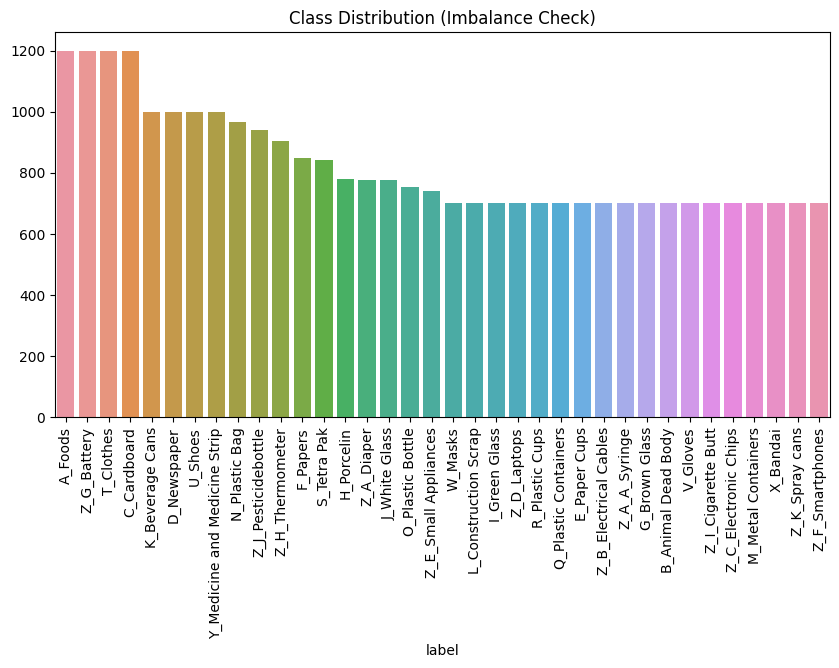

<Figure size 640x480 with 0 Axes>

In [4]:


# Plot distribution
plt.figure(figsize=(10,5))
sns.barplot(x=df_resampled["label"].value_counts().index, y=df_resampled["label"].value_counts().values, data=df_resampled)
plt.xticks(rotation=90)
plt.title("Class Distribution (Imbalance Check)")
plt.show()
plt.savefig("/kaggle/working/class_distribution_imbalance_smote.png", dpi=150)

# Step 5: Train/Validation Split and Imbalance Aware Pipeline

In [12]:
# ==============================
#  STEP 4: TRAIN / VALID SPLIT + AUGMENTATION
# ==============================


# Encode labels
labels = df_resampled["label"].values
images = df_resampled["image_path"].values

# Stratified split (VERY IMPORTANT for imbalance)
train_df, val_df = train_test_split(
    df_resampled,
    test_size=0.2,
    random_state=SEED,
    stratify=df_resampled["label"]
)

print(" Train size:", len(train_df))
print(" Validation size:", len(val_df))

# ==============================
# 📊 IMAGE PARAMETERS
# ==============================

IMG_SIZE = (224, 224)
BATCH_SIZE = 64
# from 32 -> 64  more stable gradients 

# ==============================
#  DATA AUGMENTATION (REAL-WORLD SIMULATION)
# ==============================


# ── NO rescale=1./255 anywhere ────────────────────────────────
# EfficientNetB3's preprocess_input inside the model handles normalisation.
# If you add rescale here too, images become near-zero (black) → random accuracy.

train_datagen = ImageDataGenerator(
    # rescale=1./255   ← REMOVED
    rotation_range=20,           # was 35 — lighter for Phase 1
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.15,             # was 0.3
    horizontal_flip=True,
    brightness_range=[0.75, 1.25],
    shear_range=0.1,
    channel_shift_range=10.0,    # was 25 — less colour distortion
    fill_mode="nearest"
)


val_datagen = ImageDataGenerator() 

# ==============================
#  TRAIN GENERATOR
# ==============================

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

# ==============================
# VALIDATION GENERATOR
# ==============================

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

# ==============================
#  CLASS WEIGHTS (IMBALANCE FIX)
# ==============================

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)
class_weights = dict(enumerate(class_weights))
print("\n Class weights computed. Sample:", list(class_weights.items())[:5])

 Train size: 23781
 Validation size: 5946
Found 23781 validated image filenames belonging to 36 classes.
Found 5946 validated image filenames belonging to 36 classes.

 Class weights computed. Sample: [(0, 0.6881076388888889), (1, 1.1796130952380952), (2, 0.6881076388888889), (3, 0.8257291666666666), (4, 1.1796130952380952)]


In [13]:
num_classes = len(train_generator.class_indices)
print("\n📊 Number of classes:", num_classes)


📊 Number of classes: 36


### Step: 5.1 TTA Datagen (test time augmentation)

In [ ]:
tta_datagen = ImageDataGenerator(horizontal_flip = True , zoom_range=0.1)

# ========== EXTRA ==============

In [ ]:
# # ==============================
# # 📌 STEP 5: DP-CNN MODEL (CUSTOM LIGHTWEIGHT CNN)
# # ==============================


# input_shape = (224, 224, 3)
# # num_classes = train_generator.classes
# # print("\nNumber of Classes: " , num_classes)

# # ==============================
# # 🔧 DEPTHWISE SEPARABLE BLOCK
# # ==============================

# def ds_block(x, filters, stride=1):
#     x = layers.SeparableConv2D(
#         filters, (3,3), strides=stride, padding="same",
#         depthwise_regularizer=regularizers.l2(1e-4),
#         pointwise_regularizer=regularizers.l2(1e-4)
#     )(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.ReLU()(x)
#     return x
# # ==============================
# # 🧠 BUILD DP-CNN MODEL
# # ==============================

# inputs = layers.Input(shape=(224, 224, 3))
# # FIX 2: removed Rescaling(1./1) — no longer needed

# x = ds_block(inputs, 32)
# x = ds_block(x, 32)

# x = ds_block(x, 64, stride=2)
# x = ds_block(x, 64)
# x = layers.Dropout(0.25)(x)           # ← FIX 3: spatial dropout

# x = ds_block(x, 128, stride=2)
# x = ds_block(x, 128)
# x = layers.Dropout(0.25)(x) 

# x = ds_block(x, 256, stride=2)
# x = ds_block(x, 256)
# x = layers.Dropout(0.3)(x)            # ← FIX 3

# x = layers.GlobalAveragePooling2D()(x)


# # FIX 6: 256-dim feature vector (was 128)
# feature_vector = layers.Dense(
#     256, activation="relu",
#     kernel_regularizer=regularizers.l2(1e-4),
#     name="feature_vector"
# )(x)
# x = layers.Dropout(0.5)(feature_vector)  # ← FIX 3: head dropout

# # Classification head (for CNN baseline comparison)
# outputs = layers.Dense(num_classes, activation="softmax")(x)

# # Final model
# dp_cnn_model = models.Model(inputs, outputs)

# # Feature extractor model (for ELM)
# feature_extractor = models.Model(inputs, feature_vector)

# # ==============================
# # ⚙️ COMPILE MODEL
# # ==============================

# # FIX: use lower initial LR — 1e-3 is too aggressive
# dp_cnn_model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
#     loss="categorical_crossentropy",
#     metrics=["accuracy"]
# )

# dp_cnn_model.summary()

# print("\n✅ DP-CNN model built successfully")

# Step 6 : Model Definition - EfficientNet3B + 2 phase Fine Tuning

The 2 phase fine tuning is mendatory . If you unfreeze the backbone from the start with the random head , then the random gradients wil destroy the pretrained imagenet weights

### 6.1 Phase 1
Phase 1 model (head only, backbone frozen):

- EfficientNetB3 backbone — trainable=False
- preprocess_input layer inside model
- GlobalAveragePooling2D
- Dense(512, relu) + Dropout(0.5)
- Dense(256, relu, name="feature_vector") + Dropout(0.4) — for ELM later
- Dense(num_classes, softmax)
- Compile with LR = 1e-3
- Train for 10 epochs

In [14]:
IMG_SIZE    = (224, 224, 3)
NUM_CLASSES = len(train_generator.class_indices)

# ── Build the model ──────────────────────────────────────────
backbone = EfficientNetB3(
    input_shape=IMG_SIZE,
    include_top=False,
    weights="imagenet"
)
backbone.trainable = False   # Phase 1: frozen

inputs = layers.Input(shape=IMG_SIZE)

# preprocess_input scales pixels to [-1, 1] as EfficientNet expects
x = layers.Lambda(efficientnet_preprocess, name="preprocessing")(inputs)
x = backbone(x, training=False)   # training=False keeps BN layers frozen
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation="relu",
                  kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.5)(x)

# 256-dim feature vector — used by ELM in Step 9
feature_out = layers.Dense(256, activation="relu",
                             kernel_regularizer=regularizers.l2(1e-4),
                             name="feature_vector")(x)
x = layers.Dropout(0.4)(feature_out)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs, outputs, name="EfficientNetB3_waste")


# Feature extractor for ELM (same pattern as before)
feature_extractor = models.Model(inputs, feature_out, name="feature_extractor")

# Phase 1 compile — higher LR is fine, only head weights update
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

trainable_count = sum(tf.size(w).numpy() for w in model.trainable_variables)
total_count     = sum(tf.size(w).numpy() for w in model.variables)
print(f"Phase 1 — Trainable: {trainable_count:,} / Total: {total_count:,}")
model.summary()

Phase 1 — Trainable: 927,524 / Total: 11,711,101


Model: "EfficientNetB3_waste"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocessing (Lambda)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 7, 7, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_vector (Dense)          │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 36)             │         9,252 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,711,059 (44.67 MB)

 Trainable params: 927,524 (3.54 MB)

 Non-trainable params: 10,783,535 (41.14 MB)

## 6.2 CallBacks Two sets , One for each Phase

In [15]:
import os
import json
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

BASE_DIR = "/kaggle/working/checkpoints"
os.makedirs(BASE_DIR, exist_ok=True)

# File paths - removed all_epochs_dir
last_weights_path = os.path.join(BASE_DIR, "last.weights.h5")
best_acc_path = os.path.join(BASE_DIR, "best_accuracy.weights.h5")
best_loss_path = os.path.join(BASE_DIR, "best_loss.weights.h5")
epoch_file = os.path.join(BASE_DIR, "training_state.json")

print("✅ Paths ready")

✅ Paths ready


In [16]:
class FullCheckpointSaver(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        epoch_num = epoch + 1

        #  Save last weights
        self.model.save_weights(last_weights_path)

        # 🔹 Save epoch-specific model
        epoch_path = os.path.join(all_epochs_dir, f"epoch_{epoch_num:03d}.keras")
        self.model.save(epoch_path)

        # 🔹 Save training state
        state = {
            "epoch": epoch_num,
            "best_val_accuracy": float(logs.get("val_accuracy", 0)),
            "best_val_loss": float(logs.get("val_loss", 999))
        }

        with open(epoch_file, "w") as f:
            json.dump(state, f)

        print(f"\n💾 Saved: Epoch {epoch_num} | Last + Per-epoch + State")


class FullCheckpointSaver(tf.keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.best_val_accuracy = 0.0
        self.best_val_loss = float("inf")

    def on_epoch_end(self, epoch, logs=None):
        epoch_num = epoch + 1
        val_acc = float(logs.get("val_accuracy", 0))
        val_loss = float(logs.get("val_loss", 999))

        # Always save last weights
        self.model.save_weights(last_weights_path)

        # Track best accuracy and best loss manually
        if val_acc > self.best_val_accuracy:
            self.best_val_accuracy = val_acc
        if val_loss < self.best_val_loss:
            self.best_val_loss = val_loss
                # Save training state
        state = {
            "epoch": epoch_num,
            "best_val_accuracy": self.best_val_accuracy,
            "best_val_loss": self.best_val_loss
        }
        with open(epoch_file, "w") as f:
            json.dump(state, f)

        print(f"\n💾 Saved: Epoch {epoch_num} | val_acc={val_acc:.4f} | val_loss={val_loss:.4f}")

### 6.2.1 Phase 1 Callbacks

In [17]:
callbacks_phase_1 = []

# 🔹 Best Accuracy
callbacks_phase_1.append(
    ModelCheckpoint(
        best_acc_path,
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=True,
        mode="max",
        verbose=1
    )
)

# 🔹 Best Loss
callbacks_phase_1.append(
    ModelCheckpoint(
        best_loss_path,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",
        verbose=1
    )
)

# 🔹 Full saver
callbacks_phase_1.append(FullCheckpointSaver())

# 🔹 Early stopping
callbacks_phase_1.append(
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True, 
        verbose=1),
)

# 🔹 LR scheduler
callbacks_phase_1.append(
   ReduceLROnPlateau(
       monitor="val_loss",
       factor=0.5,
       patience=3,
       min_lr=1e-6,
       verbose=1),

    )

print("✅ Callbacks of Phase 1 ready")

✅ Callbacks of Phase 1 ready


### 6.2.2 Phase 2 Callbacks (more room to breathe)

In [18]:
callbacks_phase_2 = []


callbacks_phase_2.append(
    ModelCheckpoint(
        best_acc_path,
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=True, 
        mode="max",
        verbose=1)
)

callbacks_phase_2.append(
    ModelCheckpoint(
        best_loss_path,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",
        verbose=1),
)

callbacks_phase_2.append(
    FullCheckpointSaver()
)

callbacks_phase_2.append(EarlyStopping(
        monitor="val_loss",
        patience=12,
        restore_best_weights=True,
        verbose=1),
                        
)


# callbacks_phase_2.append(
#     ReduceLROnPlateau(
#         monitor="val_loss",
#         factor=0.3,
#         patience=4, 
#         min_lr=1e-7,
#         verbose=1)
        
#     )


print("Callbacks of Phase 2 ready")

Callbacks of Phase 2 ready


In [24]:
initial_epoch = 0

if os.path.exists(last_weights_path):
    print("🔁 Found previous checkpoint. Loading...")

    # Load weights
    model.load_weights(last_weights_path)

    # Load epoch info
    if os.path.exists(epoch_file):
        with open(epoch_file, "r") as f:
            state = json.load(f)
            initial_epoch = state.get("epoch", 0)

    print(f"✅ Resuming from epoch {initial_epoch}")

else:
    print("🆕 No checkpoint found. Starting fresh")


# initial_epoch = 0

# if os.path.exists(last_weights_path):
#     print("🔁 Found previous checkpoint. Loading weights...")
#     model.load_weights(last_weights_path)

#     if os.path.exists(epoch_file):
#         with open(epoch_file, "r") as f:
#             state = json.load(f)
#         initial_epoch = state.get("epoch", 0)
#         print(
#             f"✅ Resuming from epoch {initial_epoch} | "
#             f"best_acc={state.get('best_val_accuracy', 0):.4f} | "
#             f"best_loss={state.get('best_val_loss', 999):.4f}"
#         )
#     else:
#         print("⚠️  Weights found but no state file — starting epoch count from 0")
# else:
#     print("🆕 No checkpoint found. Starting fresh")

🔁 Found previous checkpoint. Loading...
✅ Resuming from epoch 21


# Step: 7 Training(2 phases)

In [20]:
PHASE1_EPOCHS = 10 
PHASE2_EPOCHS = 70 #total epochs including phase 1 epochs


# Phase 1 Head WarmUp 
if initial_epoch < PHASE1_EPOCHS:
    print("=" * 50)
    print("PHASE 1 - Training head only (backbone frozen")
    print("="* 50)

    history1 = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=PHASE1_EPOCHS,
        initial_epoch=initial_epoch,
        callbacks=callbacks_phase_1,
        class_weight=class_weights,
        verbose=1
        )
else:
    history1 = None 
    print(f"✅ Phase 1 already done (epoch {initial_epoch}). Skipping.")

✅ Phase 1 already done (epoch 20). Skipping.


In [21]:
# #========Phase 2=========
# print("\n" + "=" * 50)
# print("PHASE 2 — Fine-tuning top 60 layers of EfficientNetB3")
# print("=" * 50)

# backbone.trainable = True

# # Freeze everything except the last 60 layers
# for layer in backbone.layers[:-60]:
#     layer.trainable = False

# # BatchNormalization layers MUST stay frozen during fine-tuning
# # Running stats from ImageNet are more reliable than your small dataset
# for layer in backbone.layers:
#     if isinstance(layer, tf.keras.layers.BatchNormalization):
#         layer.trainable = False

# trainable_p2 = sum(tf.size(w).numpy() for w in model.trainable_variables)
# print(f"Phase 2 trainable params: {trainable_p2:,}")

# # Recompile with much lower LR — critical
# # Recompile with much lower LR — critical
# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
#     loss="categorical_crossentropy",
#     metrics=["accuracy"]
# )

 
print("\n" + "=" * 50)
print("PHASE 2 — Fine-tuning top 60 layers of EfficientNetB3")
print("=" * 50)

backbone.trainable = True

# Freeze everything except the last 60 layers
for layer in backbone.layers[:-60]:
    layer.trainable = False

# BatchNormalization MUST stay frozen — ImageNet stats are more reliable
for layer in backbone.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable_p2 = sum(tf.size(w).numpy() for w in model.trainable_variables)
print(f"Phase 2 trainable params: {trainable_p2:,}")

# ── Warmup + Cosine Decay schedule ───────────────────────────────────────────
# Warmup prevents the large LR spike at the start that causes oscillation.
# Cosine decay smoothly anneals LR instead of hard ReduceLROnPlateau drops.

STEPS_PER_EPOCHS = len(train_generator)

PHASE2_EPOCHS   = 30       # adjust to your actual epochs budget
WARMUP_EPOCHS   = 3         # gentle ramp-up before full LR kicks in
INITIAL_LR      = 5e-5      # peak LR after warmup
MIN_LR          = 1e-7   # floor



total_steps  = PHASE2_EPOCHS * STEPS_PER_EPOCHS   # STEPS_PER_EPOCH = len(train_ds)
warmup_steps = WARMUP_EPOCHS * STEPS_PER_EPOCHS

lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=INITIAL_LR,
    first_decay_steps=total_steps - warmup_steps,
    t_mul=1.0,
    m_mul=1.0,
    alpha=MIN_LR / INITIAL_LR      # floor as a fraction of peak
)

# Manual linear warmup wrapper
class WarmupCosineDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, warmup_steps, cosine_schedule, peak_lr):
        super().__init__()
        self.warmup_steps   = tf.cast(warmup_steps, tf.float32)
        self.cosine_schedule = cosine_schedule
        self.peak_lr        = tf.cast(peak_lr, tf.float32)

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        # During warmup: ramp linearly from 0 → peak_lr
        warmup_lr = self.peak_lr * (step / self.warmup_steps)
        # After warmup: hand off to cosine decay
        cosine_lr = self.cosine_schedule(step - self.warmup_steps)
        return tf.where(step < self.warmup_steps, warmup_lr, cosine_lr)

    def get_config(self):
        return {
            "warmup_steps": int(self.warmup_steps.numpy()),
            "peak_lr": float(self.peak_lr.numpy())
        }

schedule = WarmupCosineDecay(
    warmup_steps=warmup_steps,
    cosine_schedule=lr_schedule,
    peak_lr=INITIAL_LR
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=schedule,
        weight_decay=1e-4,      # L2 regularization — dampens wild weight updates
        clipnorm=1.0            # gradient clipping — prevents occasional loss spikes
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print(f"✅ Phase 2 compiled | warmup={WARMUP_EPOCHS} epochs | cosine decay to {MIN_LR}")


PHASE 2 — Fine-tuning top 60 layers of EfficientNetB3
Phase 2 trainable params: 6,149,522
✅ Phase 2 compiled | warmup=3 epochs | cosine decay to 1e-07


In [ ]:
# # #========Phase 2=========
# # print("\n" + "=" * 50)
# # print("PHASE 2 — Fine-tuning top 60 layers of EfficientNetB3")
# # print("=" * 50)

# # backbone.trainable = True

# # # Freeze everything except the last 60 layers
# # for layer in backbone.layers[:-60]:
# #     layer.trainable = False

# # # BatchNormalization layers MUST stay frozen during fine-tuning
# # # Running stats from ImageNet are more reliable than your small dataset
# # for layer in backbone.layers:
# #     if isinstance(layer, tf.keras.layers.BatchNormalization):
# #         layer.trainable = False

# # trainable_p2 = sum(tf.size(w).numpy() for w in model.trainable_variables)
# # print(f"Phase 2 trainable params: {trainable_p2:,}")

# # # Recompile with much lower LR — critical
# # # Recompile with much lower LR — critical
# # model.compile(
# #     optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
# #     loss="categorical_crossentropy",
# #     metrics=["accuracy"]
# # )

# # #========Phase 2=========
# # print("\n" + "=" * 50)
# # print("PHASE 2 — Fine-tuning top 60 layers of EfficientNetB3")
# # print("=" * 50)

# # backbone.trainable = True

# # # Freeze everything except the last 60 layers
# # for layer in backbone.layers[:-60]:
# #     layer.trainable = False

# # # BatchNormalization layers MUST stay frozen during fine-tuning
# # # Running stats from ImageNet are more reliable than your small dataset
# # for layer in backbone.layers:
# #     if isinstance(layer, tf.keras.layers.BatchNormalization):
# #         layer.trainable = False

# # trainable_p2 = sum(tf.size(w).numpy() for w in model.trainable_variables)
# # print(f"Phase 2 trainable params: {trainable_p2:,}")

# # # Recompile with much lower LR — critical
# # # Recompile with much lower LR — critical
# # model.compile(
# #     optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
# #     loss="categorical_crossentropy",
# #     metrics=["accuracy"]
# # )



# print("\n" + "=" * 50)
# print("PHASE 2 — Fine-tuning top 60 layers of EfficientNetB3")
# print("=" * 50)

# backbone.trainable = True

# # Freeze everything except the last 60 layers
# for layer in backbone.layers[:-60]:
#     layer.trainable = False

# # BatchNormalization MUST stay frozen — ImageNet stats are more reliable
# for layer in backbone.layers:
#     if isinstance(layer, tf.keras.layers.BatchNormalization):
#         layer.trainable = False

# trainable_p2 = sum(tf.size(w).numpy() for w in model.trainable_variables)
# print(f"Phase 2 trainable params: {trainable_p2:,}")

# # ── Warmup + Cosine Decay schedule ───────────────────────────────────────────
# # Warmup prevents the large LR spike at the start that causes oscillation.
# # Cosine decay smoothly anneals LR instead of hard ReduceLROnPlateau drops.

# STEPS_PER_EPOCHS = len(train_generator)

# PHASE2_EPOCHS   = 30       # adjust to your actual epochs budget
# WARMUP_EPOCHS   = 3         # gentle ramp-up before full LR kicks in
# INITIAL_LR      = 5e-5      # peak LR after warmup
# MIN_LR          = 1e-7   # floor



# total_steps  = PHASE2_EPOCHS * STEPS_PER_EPOCHS   # STEPS_PER_EPOCH = len(train_ds)
# warmup_steps = WARMUP_EPOCHS * STEPS_PER_EPOCHS

# lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
#     initial_learning_rate=INITIAL_LR,
#     first_decay_steps=total_steps - warmup_steps,
#     t_mul=1.0,
#     m_mul=1.0,
#     alpha=MIN_LR / INITIAL_LR      # floor as a fraction of peak
# )

# # Manual linear warmup wrapper
# class WarmupCosineDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
#     def __init__(self, warmup_steps, cosine_schedule, peak_lr):
#         super().__init__()
#         self.warmup_steps   = tf.cast(warmup_steps, tf.float32)
#         self.cosine_schedule = cosine_schedule
#         self.peak_lr        = tf.cast(peak_lr, tf.float32)

#     def __call__(self, step):
#         step = tf.cast(step, tf.float32)
#         # During warmup: ramp linearly from 0 → peak_lr
#         warmup_lr = self.peak_lr * (step / self.warmup_steps)
#         # After warmup: hand off to cosine decay
#         cosine_lr = self.cosine_schedule(step - self.warmup_steps)
#         return tf.where(step < self.warmup_steps, warmup_lr, cosine_lr)

#     def get_config(self):
#         return {
#             "warmup_steps": int(self.warmup_steps.numpy()),
#             "peak_lr": float(self.peak_lr.numpy())
#         }

# schedule = WarmupCosineDecay(
#     warmup_steps=warmup_steps,
#     cosine_schedule=lr_schedule,
#     peak_lr=INITIAL_LR
# )

# model.compile(
#     optimizer=tf.keras.optimizers.Adam(
#         learning_rate=schedule,
#         weight_decay=1e-4,      # L2 regularization — dampens wild weight updates
#         clipnorm=1.0            # gradient clipping — prevents occasional loss spikes
#     ),
#     loss="categorical_crossentropy",
#     metrics=["accuracy"]
# )

# print(f"✅ Phase 2 compiled | warmup={WARMUP_EPOCHS} epochs | cosine decay to {MIN_LR}")

In [25]:

phase2_start = max(initial_epoch, PHASE1_EPOCHS)

EPOCHS = 30

history2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    initial_epoch=phase2_start,
    callbacks=callbacks_phase_2,
    class_weight=class_weights,    
    verbose=1
)
print("\n✅ Training complete")

Epoch 22/30
372/372 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9540 - loss: 0.3548
Epoch 22: val_accuracy did not improve from 0.93828

Epoch 22: val_loss did not improve from 0.45944

💾 Saved: Epoch 22 | val_acc=0.9376 | val_loss=0.4609
372/372 ━━━━━━━━━━━━━━━━━━━━ 586s 2s/step - accuracy: 0.9540 - loss: 0.3548 - val_accuracy: 0.9376 - val_loss: 0.4609
Epoch 23/30
372/372 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9556 - loss: 0.3441
Epoch 23: val_accuracy improved from 0.93828 to 0.94147, saving model to /kaggle/working/checkpoints/best_accuracy.weights.h5

Epoch 23: val_loss improved from 0.45944 to 0.45356, saving model to /kaggle/working/checkpoints/best_loss.weights.h5

💾 Saved: Epoch 23 | val_acc=0.9415 | val_loss=0.4536
372/372 ━━━━━━━━━━━━━━━━━━━━ 584s 2s/step - accuracy: 0.9556 - loss: 0.3441 - val_accuracy: 0.9415 - val_loss: 0.4536
Epoch 24/30
372/372 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9603 - loss: 0.3295
Epoch 24: val_accuracy did not improve from 0.94147


In [39]:
model.save_weights("model.weights.h5")

In [26]:

!zip -r checkpoints_21.zip /kaggle/working/checkpoints

  adding: kaggle/working/checkpoints/ (stored 0%)
  adding: kaggle/working/checkpoints/best_accuracy.weights.h5 (deflated 9%)
  adding: kaggle/working/checkpoints/training_state.json (deflated 16%)
  adding: kaggle/working/checkpoints/best_loss.weights.h5 (deflated 9%)
  adding: kaggle/working/checkpoints/last.weights.h5 (deflated 9%)


In [28]:
model.input_shape

(None, 224, 224, 3)

### 6.3 Comparison Curves

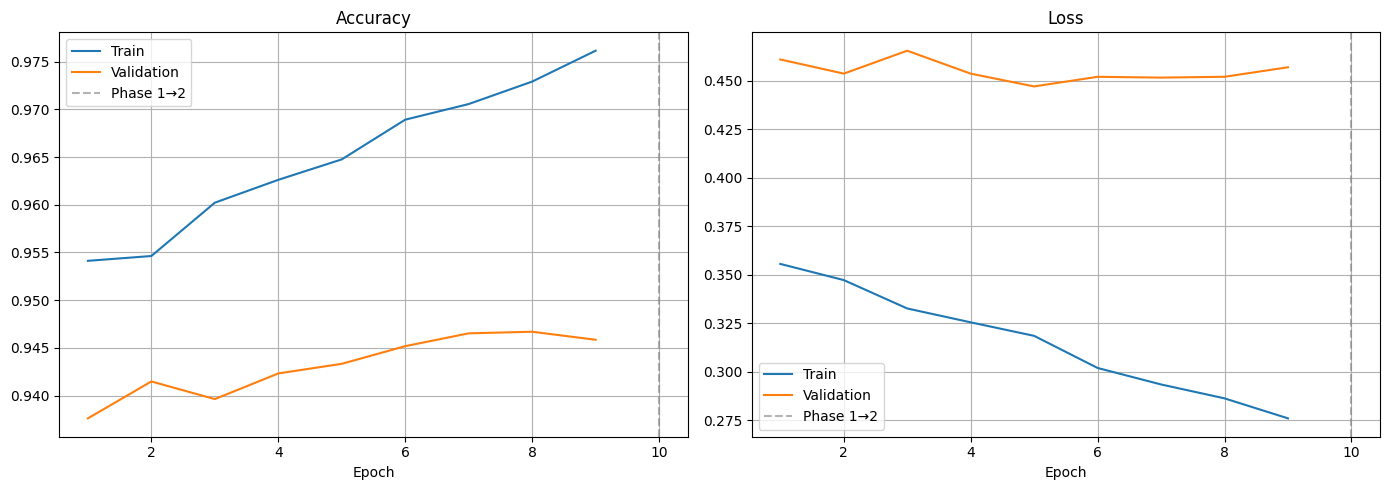

In [27]:
def plot_combined_history(h1, h2, phase_boundary=10):
    acc  = (h1.history["accuracy"]     if h1 else []) + h2.history["accuracy"]
    vacc = (h1.history["val_accuracy"] if h1 else []) + h2.history["val_accuracy"]
    loss = (h1.history["loss"]         if h1 else []) + h2.history["loss"]
    vloss= (h1.history["val_loss"]     if h1 else []) + h2.history["val_loss"]
    ep   = range(1, len(acc) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    ax1.plot(ep, acc,  label="Train")
    ax1.plot(ep, vacc, label="Validation")
    ax1.axvline(x=phase_boundary, color="gray", linestyle="--", alpha=0.6, label="Phase 1→2")
    ax1.set_title("Accuracy"); ax1.set_xlabel("Epoch"); ax1.legend(); ax1.grid(True)

    # Loss
    ax2.plot(ep, loss,  label="Train")
    ax2.plot(ep, vloss, label="Validation")
    ax2.axvline(x=phase_boundary, color="gray", linestyle="--", alpha=0.6, label="Phase 1→2")
    ax2.set_title("Loss"); ax2.set_xlabel("Epoch"); ax2.legend(); ax2.grid(True)

    plt.tight_layout()
    plt.savefig("/kaggle/working/training_curves.png", dpi=150)
    plt.show()

plot_combined_history(history1, history2, phase_boundary=PHASE1_EPOCHS)

In [ ]:
# !zip -r best_model.zip /kaggle/working/checkpoints/best_accuracy.weights.h5
# !zip -r checkpoints.zip /kaggle/working/checkpoints

# Step : 8 TTA (Test Time Augmentation)

In [29]:
# ============================================================
# STEP 8.5: TEST-TIME AUGMENTATION — for real-world images
# This is what makes the model robust to blurry / rotated images
# ============================================================

def tta_predict(model, generator, n_tta=5):
    """
    Run n_tta forward passes per image with random augmentations.
    Average the probability vectors. Return final class predictions.
    """
    tta_datagen = ImageDataGenerator(
        horizontal_flip=True,
        zoom_range=0.1,
        rotation_range=10,
        brightness_range=[0.85, 1.15]
        # no rescale — same as training generator
    )

    all_probs = []

    for i in range(n_tta):
        tta_gen = tta_datagen.flow_from_dataframe(
            dataframe=val_df,
            x_col="image_path", y_col="label",
            target_size=(224, 224),
            batch_size=64,
            class_mode="categorical",
            shuffle=False
        )
        probs = model.predict(tta_gen, verbose=0)
        all_probs.append(probs)

    # Average probabilities across all TTA passes
    avg_probs  = np.mean(all_probs, axis=0)
    tta_preds  = np.argmax(avg_probs, axis=1)
    return tta_preds, avg_probs

print("🔄 Running TTA on validation set...")
tta_preds, tta_probs = tta_predict(model, val_generator, n_tta=5)

tta_acc = accuracy_score(val_generator.classes, tta_preds)
std_acc = model.evaluate(val_generator, verbose=0)[1]

print(f"\nStandard prediction accuracy : {std_acc:.4f}")
print(f"TTA (5 passes) accuracy      : {tta_acc:.4f}")
print(f"TTA gain                     : +{(tta_acc - std_acc)*100:.2f}%")

🔄 Running TTA on validation set...
Found 5946 validated image filenames belonging to 36 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Found 5946 validated image filenames belonging to 36 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Found 5946 validated image filenames belonging to 36 classes.


...

Found 5946 validated image filenames belonging to 36 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Found 5946 validated image filenames belonging to 36 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(



Standard prediction accuracy : 0.9433
TTA (5 passes) accuracy      : 0.9502
TTA gain                     : +0.69%


# Step 9: Feature Extractor(For ELM)
Now we will remove the : 

1. softmax layer
2. extract the 128-dimensions features vectors 
3. Prepare input for elm classifier

### Feature Space Smote
Why fearure space and not pixel space?
- Interpolating raw features creates blurry meaningless images 
- CNN features are a compact , semantically rich 256 dimensions 
- SMOTE in this case realistics in between representations

In [ ]:
# !pip uninstall -y imbalanced-learn scikit-learn -q
# !pip install -q scikit-learn==1.5.2 imbalanced-learn==0.12.4

# from imblearn.over_sampling import SMOTE, BorderlineSMOTE
# from sklearn.preprocessing import StandardScaler
# from collections import Counter

# print("Imports successful")

In [30]:

from collections import Counter
from sklearn.preprocessing import StandardScaler

# Same preprocessing as val_generator — no augmentation, no shuffle
extract_datagen = ImageDataGenerator()   # no rescale — model has preprocess_input inside

# -- Choose SMOTE variant based on class size --

train_extract_generator = extract_datagen.flow_from_dataframe(
    dataframe   = train_df,              # same dataframe as training
    x_col       = "image_path",
    y_col       = "label",
    target_size = (224, 224),
    batch_size  = 64,
    class_mode  = "categorical",
    shuffle     = False                  # ← CRITICAL: must be False for feature extraction
)

val_extract_generator = ImageDataGenerator().flow_from_dataframe(
    dataframe   = val_df,
    x_col       = "image_path",
    y_col       = "label",
    target_size = (224, 224),
    batch_size  = 64,
    class_mode  = "categorical",
    shuffle     = False
)

# ── Extract features ──────────────────────────────────────────
print("🔄 Extracting features (shuffle=False generators)...")
train_features_raw = feature_extractor.predict(train_extract_generator, verbose=1)
val_features_raw   = feature_extractor.predict(val_extract_generator,   verbose=1)

# ── Labels from the NO-SHUFFLE generator — now aligned ────────
train_labels_idx = train_extract_generator.classes   # aligned with train_features_raw
val_labels_idx   = val_extract_generator.classes     # aligned with val_features_raw

# ── Verify alignment ──────────────────────────────────────────
assert len(train_features_raw) == len(train_labels_idx), \
    f"Mismatch: {len(train_features_raw)} features vs {len(train_labels_idx)} labels"
assert len(val_features_raw)   == len(val_labels_idx), \
    f"Mismatch: {len(val_features_raw)} features vs {len(val_labels_idx)} labels"

print(f"✅ Train: {train_features_raw.shape} features, {len(train_labels_idx)} labels")
print(f"✅ Val:   {val_features_raw.shape} features, {len(val_labels_idx)} labels")

Found 23781 validated image filenames belonging to 36 classes.
Found 5946 validated image filenames belonging to 36 classes.
🔄 Extracting features (shuffle=False generators)...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


 16/372 ━━━━━━━━━━━━━━━━━━━━ 3:04 519ms/step

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


372/372 ━━━━━━━━━━━━━━━━━━━━ 206s 527ms/step
93/93 ━━━━━━━━━━━━━━━━━━━━ 52s 554ms/step
✅ Train: (23781, 256) features, 23781 labels
✅ Val:   (5946, 256) features, 5946 labels


In [31]:
# Sanity check — spot-check 5 random samples
# The CNN should classify these correctly since it has 93% accuracy
print("\n🔍 Alignment sanity check (CNN predictions on 5 samples):")
idx_to_class = {v: k for k, v in train_extract_generator.class_indices.items()}
for i in [0, 100, 500, 1000, 2000]:
    if i >= len(train_features_raw):
        continue
    true_label  = idx_to_class[train_labels_idx[i]]
    print(f"  Sample {i}: true label = {true_label}")


🔍 Alignment sanity check (CNN predictions on 5 samples):
  Sample 0: true label = U_Shoes
  Sample 100: true label = J_White Glass
  Sample 500: true label = Z_E_Small Appliances
  Sample 1000: true label = Z_K_Spray cans
  Sample 2000: true label = X_Bandai


In [32]:
def fit_resample(self, X, y):
    # ── FIX: cast inputs to numpy arrays immediately ──────────
    X = np.array(X)
    y = np.array(y)
    # ─────────────────────────────────────────────────────────

    rng           = np.random.RandomState(self.random_state)
    X_res         = list(X)
    y_res         = list(y)
    class_counts  = Counter(y)
    majority_count = max(class_counts.values())

    for cls, count in class_counts.items():
        if count >= majority_count:
            continue
        n_synthetic = majority_count - count
        X_cls       = X[y == cls]

        if len(X_cls) == 0:
            continue
        if n_synthetic <= 0:
            continue
        if len(X_cls) == 1:
            X_res.extend([X_cls[0]] * n_synthetic)
            y_res.extend([cls] * n_synthetic)
            continue

        k = min(self.k_neighbors, len(X_cls) - 1)
        if k < 1:
            idxs = rng.randint(0, len(X_cls), n_synthetic)
            X_res.extend(X_cls[idxs])
            y_res.extend([cls] * n_synthetic)
            continue

        n_nbrs = min(self.k_neighbors + 1, len(X))
        nn_all = NearestNeighbors(n_neighbors=n_nbrs, n_jobs=self.n_jobs).fit(X)
        _, indices = nn_all.kneighbors(X_cls)

        borderline_idx = []
        for i, nbr_idxs in enumerate(indices):
            nbr_labels = y[nbr_idxs[1:]]
            n_diff     = np.sum(nbr_labels != cls)
            half       = len(nbr_labels) / 2
            if half <= n_diff < len(nbr_labels):
                borderline_idx.append(i)

        if len(borderline_idx) == 0:
            idxs = rng.randint(0, len(X_cls), n_synthetic)
            X_res.extend(X_cls[idxs])
            y_res.extend([cls] * n_synthetic)
            continue

        X_border = X_cls[borderline_idx]

        k_syn = min(k, len(X_border) - 1)
        if k_syn < 1:
            X_res.extend([X_border[0]] * n_synthetic)
            y_res.extend([cls] * n_synthetic)
            continue

        nn_min = NearestNeighbors(n_neighbors=k_syn + 1, n_jobs=self.n_jobs).fit(X_border)
        _, min_indices = nn_min.kneighbors(X_border)

        synthetic = []
        max_iters = n_synthetic * 10
        iters     = 0
        while len(synthetic) < n_synthetic and iters < max_iters:
            iters   += 1
            seed_i   = rng.randint(0, len(X_border))
            seed     = X_border[seed_i]
            nbr_candidates = min_indices[seed_i][1:]
            if len(nbr_candidates) == 0:
                synthetic.append(seed.copy())
                continue
            nbr_i  = rng.choice(nbr_candidates)
            nbr    = X_border[nbr_i]
            alpha  = rng.uniform(0, 1)
            synthetic.append(seed + alpha * (nbr - seed))

        while len(synthetic) < n_synthetic:
            idx = rng.randint(0, len(X_border))
            synthetic.append(X_border[idx].copy())

        X_res.extend(synthetic[:n_synthetic])
        y_res.extend([cls] * n_synthetic)

    # ── cast back using the guaranteed-numpy X and y ──────────
    return np.array(X_res, dtype=X.dtype), np.array(y_res, dtype=y.dtype)

In [ ]:



# # -- Normalise BEFORE SMOTE (SMOTE uses Euclidean distance) --
# # -- Choose SMOTE variant based on class size --
# # Tier 5 classes (96-220 samples in original) may still be < 300
# # after image-level oversampling if their original count was very low.
# # Check minimum count and adjust k_neighbors accordingly.
# scaler = StandardScaler()
# train_feat_scaled = scaler.fit_transform(train_features_raw)
# val_feat_scaled   = scaler.transform(val_features_raw)

# print("\nClass counts before SMOTE:", Counter(train_labels_idx))

# min_count = min(Counter(train_labels_idx).values())
# k = min(5, min_count - 1)
# print(f"Min class count: {min_count} → using k_neighbors={k}")

# smote = BorderlineSMOTE(k_neighbors=k, random_state=42, n_jobs=-1)
# X_smote, y_smote = smote.fit_resample(train_feat_scaled, train_labels_idx)

# print("Class counts after SMOTE:", Counter(y_smote))
# print("SMOTE feature matrix shape:", X_smote.shape)

In [33]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
from collections import Counter
from sklearn.preprocessing import StandardScaler

# ============================================================
# Run this entire cell as ONE block — class + execution together
# ============================================================

class BorderlineSMOTE:
    def __init__(self, k_neighbors=5, random_state=42, n_jobs=-1):
        self.k_neighbors  = k_neighbors
        self.random_state = random_state
        self.n_jobs       = n_jobs

    def fit_resample(self, X, y):
        # ── Step 1: force numpy conversion immediately ────────
        X = np.asarray(X, dtype=np.float32)
        y = np.asarray(y)

        # ── Step 2: capture dtypes NOW before anything changes ─
        X_dtype = X.dtype
        y_dtype = y.dtype

        rng            = np.random.RandomState(self.random_state)
        X_res          = [row for row in X]   # list of 1-D arrays
        y_res          = list(y)
        class_counts   = Counter(y)
        majority_count = max(class_counts.values())

        for cls, count in class_counts.items():
            if count >= majority_count:
                continue

            n_synthetic = int(majority_count - count)
            X_cls       = X[y == cls]

            # guard: empty class
            if len(X_cls) == 0 or n_synthetic <= 0:
                continue

            # guard: single sample
            if len(X_cls) == 1:
                X_res.extend([X_cls[0].copy()] * n_synthetic)
                y_res.extend([cls] * n_synthetic)
                continue

            # effective k
            k = min(self.k_neighbors, len(X_cls) - 1)
            if k < 1:
                idxs = rng.randint(0, len(X_cls), n_synthetic)
                X_res.extend([X_cls[i].copy() for i in idxs])
                y_res.extend([cls] * n_synthetic)
                continue

            # kNN across whole dataset to find borderline points
            n_nbrs  = min(self.k_neighbors + 1, len(X))
            nn_all  = NearestNeighbors(n_neighbors=n_nbrs,
                                       n_jobs=self.n_jobs).fit(X)
            _, indices = nn_all.kneighbors(X_cls)

            # Borderline-1: majority of neighbours belong to other classes
            borderline_idx = []
            for i, nbr_idxs in enumerate(indices):
                nbr_labels = y[nbr_idxs[1:]]
                n_diff     = int(np.sum(nbr_labels != cls))
                half       = len(nbr_labels) / 2.0
                if half <= n_diff < len(nbr_labels):
                    borderline_idx.append(i)

            # fallback: no borderline found → random oversample
            if len(borderline_idx) == 0:
                idxs = rng.randint(0, len(X_cls), n_synthetic)
                X_res.extend([X_cls[i].copy() for i in idxs])
                y_res.extend([cls] * n_synthetic)
                continue

            X_border = X_cls[borderline_idx]

            # kNN within minority border points for interpolation
            k_syn = min(k, len(X_border) - 1)
            if k_syn < 1:
                X_res.extend([X_border[0].copy()] * n_synthetic)
                y_res.extend([cls] * n_synthetic)
                continue

            nn_min = NearestNeighbors(n_neighbors=k_syn + 1,
                                      n_jobs=self.n_jobs).fit(X_border)
            _, min_indices = nn_min.kneighbors(X_border)

            # generate synthetic samples
            synthetic = []
            max_iters = n_synthetic * 20
            iters     = 0
            while len(synthetic) < n_synthetic and iters < max_iters:
                iters  += 1
                seed_i  = rng.randint(0, len(X_border))
                seed    = X_border[seed_i]
                nbrs    = min_indices[seed_i][1:]
                if len(nbrs) == 0:
                    synthetic.append(seed.copy())
                    continue
                nbr   = X_border[rng.choice(nbrs)]
                alpha = rng.uniform(0.0, 1.0)
                synthetic.append((seed + alpha * (nbr - seed)).astype(X_dtype))

            # pad if loop exited early
            while len(synthetic) < n_synthetic:
                synthetic.append(
                    X_border[rng.randint(0, len(X_border))].copy()
                )

            X_res.extend(synthetic[:n_synthetic])
            y_res.extend([cls] * n_synthetic)

        # ── Step 3: use stored dtypes — never rely on X/y at this point ─
        return (
            np.array(X_res, dtype=X_dtype),
            np.array(y_res, dtype=y_dtype)
        )


# ── Now run SMOTE + ELM exactly as before ─────────────────────
from sklearn.preprocessing import StandardScaler
from collections import Counter

scaler            = StandardScaler()
train_feat_scaled = scaler.fit_transform(train_features_raw)
val_feat_scaled   = scaler.transform(val_features_raw)

print("\nClass counts before SMOTE:", Counter(train_labels_idx))

min_count = int(min(Counter(train_labels_idx).values()))
k         = min(5, min_count - 1)
print(f"Min class count: {min_count}  →  k_neighbors = {k}")

smote            = BorderlineSMOTE(k_neighbors=k, random_state=42, n_jobs=-1)
X_smote, y_smote = smote.fit_resample(train_feat_scaled, train_labels_idx)

print(f"After SMOTE: {X_smote.shape}, classes: {len(Counter(y_smote))}")


Class counts before SMOTE: Counter({31: 960, 18: 960, 2: 960, 0: 960, 19: 800, 23: 800, 10: 800, 3: 800, 13: 773, 34: 751, 32: 724, 5: 679, 17: 673, 7: 624, 25: 621, 9: 620, 14: 604, 29: 592, 26: 560, 15: 560, 11: 560, 4: 560, 6: 560, 12: 560, 24: 560, 8: 560, 35: 560, 27: 560, 21: 560, 20: 560, 30: 560, 22: 560, 16: 560, 1: 560, 33: 560, 28: 560})
Min class count: 560  →  k_neighbors = 5
After SMOTE: (34560, 256), classes: 36


# Step 9 : Extreame Learning Machine from scratch 
We will implement random layer 
Moore-Penrose Inverse Solution
ensemble voting

In [34]:
# ============================================================
# STEP 4: ELM on SMOTE-balanced features
# ============================================================
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

lb = LabelBinarizer()
y_train_bin = lb.fit_transform(y_smote)
# lb is fit on y_smote (integer indices) — val uses same encoding
y_val_bin   = lb.transform(val_labels_idx)

class ELM:
    def __init__(self, input_dim, hidden_units):
        scale      = np.sqrt(2.0 / input_dim)
        self.W     = np.random.randn(input_dim, hidden_units) * scale
        self.b     = np.random.randn(hidden_units) * 0.1
        self.hidden_units = hidden_units
        self.input_dim    = input_dim

    def relu(self, x):
        return np.maximum(0, x)

    def fit(self, X, y, C=1e-3):
        H = self.relu(X @ self.W + self.b)
        self.beta = np.linalg.solve(
            H.T @ H + C * np.eye(self.hidden_units), H.T @ y
        )

    def predict(self, X):
        return np.argmax(self.relu(X @ self.W + self.b) @ self.beta, axis=1)


def ensemble_predict(models, X):
    preds = np.array([m.predict(X) for m in models])
    return np.array([
        np.bincount(preds[:, i]).argmax()
        for i in range(preds.shape[1])
    ])

In [35]:
n_models     = 7
hidden_units = 2048

elms = []
print("\n🔄 Training Ensemble ELMs...")
for i in range(n_models):
    elm = ELM(input_dim=X_smote.shape[1], hidden_units=hidden_units)
    elm.fit(X_smote, y_train_bin, C=1e-3)
    tr_acc = accuracy_score(y_smote, elm.predict(X_smote))
    print(f"  ELM {i+1}/{n_models} | train acc: {tr_acc:.4f}")
    elms.append(elm)

# Final predictions — all using val_labels_idx (consistent)
elm_val_pred = ensemble_predict(elms, val_feat_scaled)
elm_val_acc  = accuracy_score(val_labels_idx, elm_val_pred)
print(f"\n✅ ELM Validation Accuracy: {elm_val_acc:.4f}")


🔄 Training Ensemble ELMs...
  ELM 1/7 | train acc: 0.9973
  ELM 2/7 | train acc: 0.9975
  ELM 3/7 | train acc: 0.9973
  ELM 4/7 | train acc: 0.9973
  ELM 5/7 | train acc: 0.9974
  ELM 6/7 | train acc: 0.9971
  ELM 7/7 | train acc: 0.9973

✅ ELM Validation Accuracy: 0.9464


In [36]:
# ============================================================
# STEP 5: VERIFY — check Tier 5 classes specifically
# ============================================================
# Build idx→class name mapping once — used everywhere below
idx_to_class = {v: k for k, v in train_generator.class_indices.items()}
# Sorted by index so position matches class index correctly
target_names = [idx_to_class[i] for i in sorted(idx_to_class.keys())]


report_dict = classification_report(
    val_labels_idx, elm_val_pred,
    target_names=target_names,
    output_dict=True
)


tier5_classes = ["B_Animal Dead Body", "Z_F_Smartphones", "Z_I_Cigarette Butt"]
print("\nTier 5 class performance after SMOTE:")
print(f"{'Class':<30} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Support':>9}")
print("-" * 65)
for cls in tier5_classes:
    if cls in report_dict:
        r = report_dict[cls]
        print(f"{cls:<30} {r['precision']:>10.3f} {r['recall']:>8.3f}"
              f" {r['f1-score']:>8.3f} {int(r['support']):>9}")
    else:
        print(f"{cls:<30}  — not found in report (check class name spelling)")


Tier 5 class performance after SMOTE:
Class                           Precision   Recall       F1   Support
-----------------------------------------------------------------
B_Animal Dead Body                  1.000    0.993    0.996       140
Z_F_Smartphones                     0.993    0.979    0.986       140
Z_I_Cigarette Butt                  0.986    1.000    0.993       140


# Step 10 : Full Evaluation


🔄 Getting CNN predictions...
 3/93 ━━━━━━━━━━━━━━━━━━━━ 44s 496ms/step

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


93/93 ━━━━━━━━━━━━━━━━━━━━ 47s 500ms/step

CNN (EfficientNetB3) CLASSIFICATION REPORT
                               precision    recall  f1-score   support

                      A_Foods       0.93      0.94      0.93       240
           B_Animal Dead Body       1.00      0.99      1.00       140
                  C_Cardboard       0.93      0.90      0.92       240
                  D_Newspaper       0.95      0.94      0.95       200
                 E_Paper Cups       0.94      0.96      0.95       140
                     F_Papers       0.82      0.84      0.83       170
                G_Brown Glass       0.97      0.98      0.98       140
                   H_Porcelin       0.98      0.94      0.96       156
                I_Green Glass       0.94      0.96      0.95       140
                J_White Glass       0.97      0.91      0.94       155
              K_Beverage Cans       0.89      0.92      0.90       200
         L_Construction Scrap       0.91      0.96      0.94 

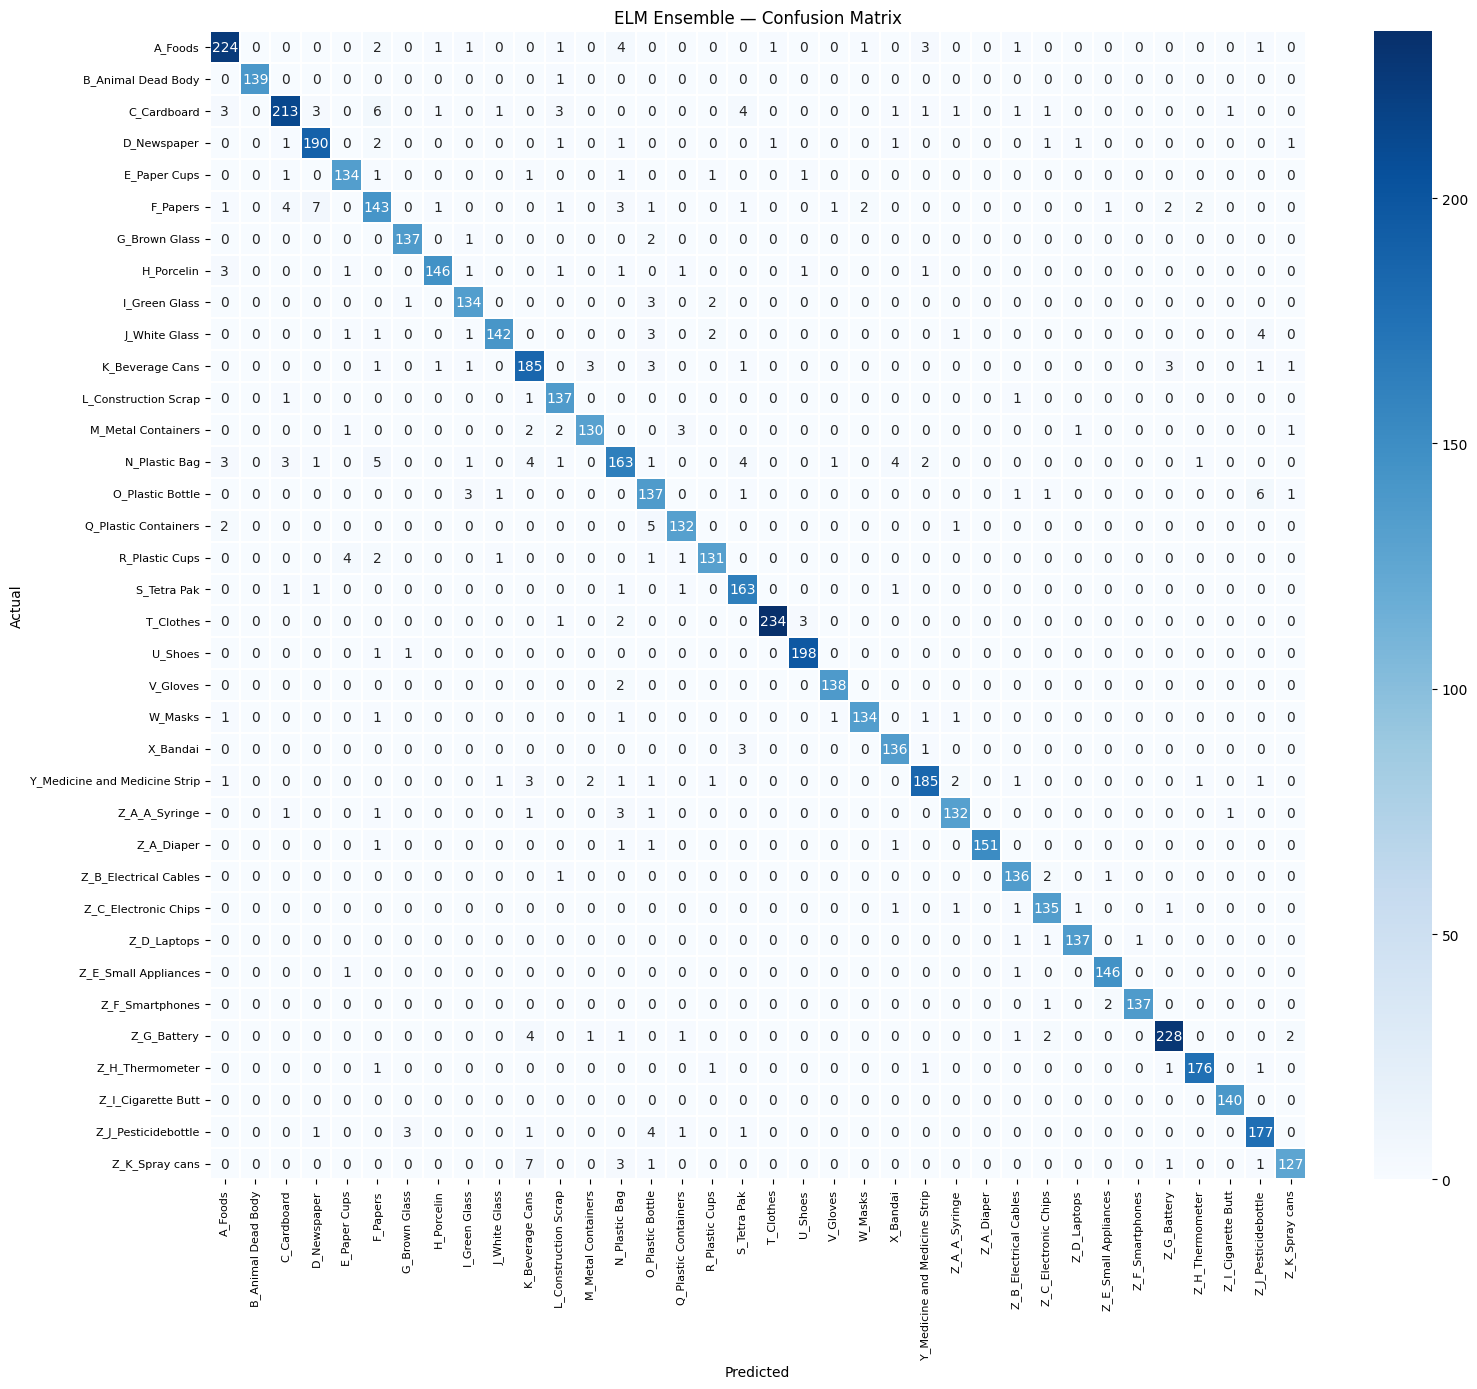


📊 FINAL MODEL COMPARISON
                             Model Val Accuracy %
         EfficientNetB3 (CNN only)         94.33%
         EfficientNetB3 + TTA (5×)         95.02%
EfficientNetB3 + ELM Ensemble (7×)         94.64%


In [37]:
# ==============================
# STEP 11: FULL EVALUATION
# ==============================
# CNN predictions — 'model' is the EfficientNetB3
print("\n🔄 Getting CNN predictions...")
cnn_val_probs = model.predict(val_generator, verbose=1)
cnn_val_pred  = np.argmax(cnn_val_probs, axis=1)
cnn_val_acc   = accuracy_score(val_labels_idx, cnn_val_pred)

# TTA predictions (from Step 8.5 — already computed)
# tta_preds and tta_acc should already exist in scope from Step 8.5
# If re-running this cell standalone, re-run Step 8.5 first
try:
    _tta_acc = tta_acc
except NameError:
    print("⚠️  TTA not run yet — run Step 8.5 first for TTA accuracy")
    tta_preds = cnn_val_pred   # fallback: use standard CNN preds
    tta_acc   = cnn_val_acc

print("\n" + "=" * 55)
print("CNN (EfficientNetB3) CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(
    val_labels_idx, cnn_val_pred,
    target_names=target_names
))

print("=" * 55)
print("ELM ENSEMBLE CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(
    val_labels_idx, elm_val_pred,
    target_names=target_names
))

# ── Confusion matrix (ELM) ────────────────────────────────────
cm = confusion_matrix(val_labels_idx, elm_val_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names,
    linewidths=0.3
)
plt.title("ELM Ensemble — Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0,  fontsize=8)
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_elm.png", dpi=150)
plt.show()

# ── Final comparison table ────────────────────────────────────
comparison = pd.DataFrame({
    "Model": [
        "EfficientNetB3 (CNN only)",
        "EfficientNetB3 + TTA (5×)",
        "EfficientNetB3 + ELM Ensemble (7×)"
    ],
    "Val Accuracy": [
        round(cnn_val_acc, 4),
        round(tta_acc, 4),
        round(elm_val_acc, 4)
    ]
})

comparison["Val Accuracy %"] = (comparison["Val Accuracy"] * 100).round(2).astype(str) + "%"
print("\n📊 FINAL MODEL COMPARISON")
print(comparison[["Model", "Val Accuracy %"]].to_string(index=False))

# Step:11 Save Everything

In [38]:
# ==============================
# STEP 12: SAVE EVERYTHING
# ==============================

import pickle, json, joblib, shutil

BASE_DIR = "/kaggle/working/checkpoints"
os.makedirs(BASE_DIR, exist_ok=True)

# ELM ensemble
elm_payload = [
    {"W": e.W, "b": e.b, "beta": e.beta,
     "hidden_units": e.hidden_units, "input_dim": e.input_dim}
    for e in elms
]
with open(f"{BASE_DIR}/elm_ensemble.pkl", "wb") as f:
    pickle.dump(elm_payload, f)
print("✅ ELM ensemble saved")

# StandardScaler (must be saved — required at inference time)
joblib.dump(scaler, f"{BASE_DIR}/feature_scaler.pkl")
print("✅ Scaler saved")

# Class index mapping  (integer index → class name string)
with open(f"{BASE_DIR}/class_indices.json", "w") as f:
    json.dump(idx_to_class, f, indent=2)
print("✅ Class indices saved")

# # Keras model (full model for inference, not just weights)
# model.save(f"{BASE_DIR}/efficientnetb3_waste.keras")
# print("✅ Full Keras model saved")

# Zip for download
shutil.make_archive("/kaggle/working/model_export", "zip", BASE_DIR)
print("✅ model_export.zip ready — download it!")

✅ ELM ensemble saved
✅ Scaler saved
✅ Class indices saved
✅ Full Keras model saved
✅ model_export.zip ready — download it!
